In [1]:
from pathlib import Path
import copy
import pandas as pd
import datetime
from datetime import datetime
from liblaf import grapes
import polars as pl


In [2]:
from qoc.market import  BinanceMarketData,BinanceDataCollectionFuturesUm
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()


# symbols: list[str] = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT', 'SPXUSDT']
symbols: list[str] = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT']
interval: str = "1m"


start: str = "2025-04-01"
end: str  = "2025-09-30"
    
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()



In [3]:
with grapes.timer():

    coin_dict: dict[str, pl.DataFrame] = await market_data.klines_batch(
        symbols, interval, start, end
    )

# Preload

In [4]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os


In [5]:
start_time = datetime.strptime(start, "%Y-%m-%d")
end_time = datetime.strptime(end, "%Y-%m-%d")

In [6]:
start_time = start
end_time = end

In [7]:
hedge_list: dict[str, pd.DataFrame] = {}
for symbol, df in coin_dict.items():
    df = pd.DataFrame(df.to_dicts())
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms').dt.tz_localize(None)
    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms').dt.tz_localize(None)

    df.set_index('open_time', inplace=True)
    # print(df.index.min(), df.index.max())
    hedge_list[symbol] = df
coin_dict = None  # release memory

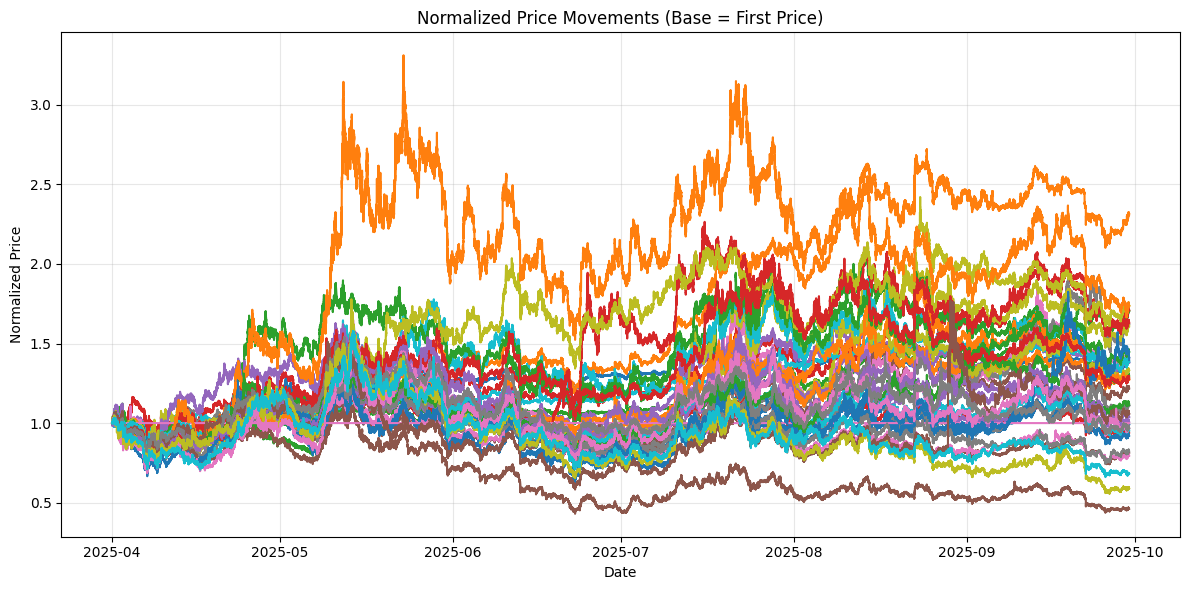

In [8]:
plt.figure(figsize=(12, 6))
for symbol, df in hedge_list.items():
    if len(df) > 0:  # Check if dataframe is not empty
        # Normalize to first price
        normalized_prices = df["close"] / df["close"].iloc[0]
        plt.plot(df.index, normalized_prices, label=symbol)

plt.title('Normalized Price Movements (Base = First Price)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Para

In [9]:

FORWARD_WINDOW =30
BACK_WINDOW = 120
BULLET_SIZE = 50

# Stats

## Split

In [10]:
# Remove MATICUSDT from hedge_list

if 'MATICUSDT' in hedge_list:
    del hedge_list['MATICUSDT']
    print("MATICUSDT removed from hedge_list")
else:
    print("MATICUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

if 'FTMUSDT' in hedge_list:
    del hedge_list['FTMUSDT']
    print("FTMUSDT removed from hedge_list")
else:
    print("FTMUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

MATICUSDT not found in hedge_list
Remaining symbols in hedge_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT']
FTMUSDT removed from hedge_list
Remaining symbols in hedge_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MO

In [11]:
coin_list = list(hedge_list.keys())

split_date = datetime(2025, 7, 31)

train_list = {}
test_list = {}

for symbol, df in hedge_list.items():
    train_list[symbol] = df[df.index < split_date]
    test_list[symbol] = df[df.index >= split_date]

# # release memory
# hedge_list = None

In [12]:
data_list = train_list

## Regress

In [13]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


# btc_close = deque(btc['close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['close'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


# btc_volume = deque(btc['volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['volume'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


xy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
xx_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
yy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
x_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
y_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}


xy_1_sum = {name: 0 for name in hedge_list.keys()}
xx_1_sum = {name: 0 for name in hedge_list.keys()}
yy_1_sum = {name: 0 for name in hedge_list.keys()}
x_1_sum = {name: 0 for name in hedge_list.keys()}
y_1_sum = {name: 0 for name in hedge_list.keys()}

# Trade

In [14]:
lc = None
sc = None
sam = 0
dif = 0

In [15]:
windows = [0.25, 0.5 , 1, 4, 16, 64, 256]
for i in range(len(windows)):
    windows[i] = int(BACK_WINDOW*windows[i])
windows

[30, 60, 120, 480, 1920, 7680, 30720]

In [16]:
# Initialize coef_records
coef_records = {}

revenues = []


# regression stats
    # Residual difference between short and long
    # Residual mean/std

    # Residual z-score all
    # Residual z-score selected
    # Residual sign

    # corr all
    # corr selected

stats_global = {
    "residual_diff": [],
    "residual_std": [],
    "residual_mean": [],
    "residual_z_all": [],
    "residual_z_selected": [],
    "residual_sign": [],
    "corr_all": [],
    "corr_selected": [],
    "coef_adj_all": [],
    "coef_adj_selected": [],
}


# stats by windows
    # growth diff all
    # growth diff selected
    # growth diff sign

    # Amihud all
    # Amihud selected

    # CMI all
    # CMI selected

    # coin score all
    # coin score selected

    # ATR all
    # ATR selected

    # Bollinger Bands all
    # Bollinger Bands selected

    # Volatility all
    # Volatility selected

stats_list = [
    "close_ret",
    "amihud",
    "cmi",
    "coin",
    "atr",
    "bb",
    "std",
]


stats_by_window = {}

for stat in stats_list:
    for scope in ["all", "selected"]:
        key = f"{stat}_{scope}"
        stats_by_window[key] = {w: [] for w in windows}


## Coin_score
temp_revs= {name: deque([0] * (forward_window + 1), maxlen=forward_window + 1) for name in hedge_list.keys()}

coin_scores = {name: {w: 0 for w in windows} for name in hedge_list.keys()}


In [17]:
temp_revs

{'BTCUSDT': deque([0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0],
       maxlen=31),
 'ETHUSDT': deque([0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0],
       maxlen=31),
 'BNBUSDT': deque([0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
   

In [18]:
stats_nocs_list = [
    "close_ret",
    "amihud",
    "cmi",
    "atr",
    "bb",
    "std",
]

In [19]:
for tqdm_idx, (symbol, df) in tqdm(enumerate(data_list.items())):

    df = df.copy()
    ## growth
    for w in windows:
        df[f"close_ret_{w}"] = (
            np.log(df["close"])
            - np.log(df["close"].shift(w))
        )
    ## Amihud
    for w in windows:
        df[f"amihud_{w}"] = (
            np.log(df["close"])
            .diff()
            .rolling(w, min_periods=w)
            .sum()
            .abs()
            /
            (df["close"] * df["volume"])
            .rolling(w, min_periods=w)
            .sum()
        )
        df.dropna(inplace=True)           
        
    ## CMI
    for w in windows:
        tr = np.maximum(
            df["high"] - df["low"],
            np.maximum(
                (df["high"] - df["close"].shift(1)).abs(),
                (df["low"]  - df["close"].shift(1)).abs()
            )
        )
        df[f"cmi_{w}"] = (
            100.0
            * np.log10(
                tr.rolling(w, min_periods=w).sum()
                /
                (
                    df["high"].rolling(w, min_periods=w).max()
                    - df["low"].rolling(w, min_periods=w).min()
                )
            )
            / np.log10(w)
        )

    ## ATR
    for w in windows:
        tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"]  - df["close"].shift(1)).abs()
        )
        )

        df[f"atr_{w}"] = tr.rolling(w, min_periods=w).mean()
    ## Bollinger
    for w in windows:
        df[f"bb_std_dev_{w}"] = (
            (
                df["close"]
                -
                df["close"].rolling(w, min_periods=w).mean()
            )
            /
            df["close"].rolling(w, min_periods=w).std()
        )
    ## Std
    for w in windows:
        df[f"std_{w}"] = (
            np.log(df["close"]).diff()
            .rolling(w, min_periods=w)
            .std()
        )
    df.dropna(inplace=True)           

    data_list[symbol] = df


39it [00:08,  4.78it/s]


In [20]:
data_list['BTCUSDT']



,open,high,low,close,volume,close_time,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,...,bb_std_dev_1920,bb_std_dev_7680,bb_std_dev_30720,std_30,std_60,std_120,std_480,std_1920,std_7680,std_30720
open_time,,,,,,,,,,,,,,,,,,,,,
2025-06-11 03:00:00,109642.2,109674.5,109616.2,109657.8,53.393,2025-06-11 03:00:59.999,5.854872e+06,1441,28.904,3.169450e+06,...,0.523130,1.518954,1.235004,0.000230,0.000272,0.000305,0.000468,0.000483,0.000426,0.000504
2025-06-11 03:01:00,109657.8,109657.8,109647.5,109647.9,14.620,2025-06-11 03:01:59.999,1.603082e+06,568,7.447,8.165553e+05,...,0.500588,1.514313,1.230612,0.000229,0.000272,0.000305,0.000468,0.000483,0.000426,0.000504
2025-06-11 03:02:00,109647.9,109663.1,109647.8,109650.2,28.536,2025-06-11 03:02:59.999,3.128995e+06,865,25.431,2.788519e+06,...,0.504834,1.514873,1.231529,0.000228,0.000272,0.000303,0.000468,0.000483,0.000426,0.000504
2025-06-11 03:03:00,109650.1,109660.6,109650.1,109658.1,23.776,2025-06-11 03:03:59.999,2.607117e+06,543,18.037,1.977786e+06,...,0.521422,1.517820,1.234884,0.000219,0.000270,0.000301,0.000467,0.000483,0.000426,0.000504
2025-06-11 03:04:00,109658.0,109670.9,109658.0,109670.9,15.649,2025-06-11 03:04:59.999,1.716145e+06,526,14.225,1.559976e+06,...,0.548841,1.522858,1.240371,0.000215,0.000269,0.000301,0.000466,0.000483,0.000426,0.000504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-30 23:55:00,117750.8,117795.9,117749.8,117792.8,74.193,2025-07-30 23:55:59.999,8.738218e+06,1270,41.665,4.907101e+06,...,0.227119,-0.373761,0.004975,0.000267,0.000245,0.000274,0.000496,0.000435,0.000372,0.000480
2025-07-30 23:56:00,117792.9,117818.7,117792.8,117812.9,59.455,2025-07-30 23:56:59.999,7.004657e+06,977,24.934,2.937474e+06,...,0.273909,-0.346081,0.015167,0.000265,0.000240,0.000274,0.000494,0.000435,0.000372,0.000480
2025-07-30 23:57:00,117813.0,117813.0,117771.0,117771.1,38.681,2025-07-30 23:57:59.999,4.556119e+06,1030,8.970,1.056522e+06,...,0.175260,-0.405535,-0.006480,0.000278,0.000246,0.000272,0.000494,0.000435,0.000372,0.000480


In [21]:
coin_scores

{'BTCUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ETHUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'BNBUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'SOLUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'XRPUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ADAUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'DOGEUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'AVAXUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'LINKUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'TRXUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'DOTUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'LTCUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'UNIUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ATOMUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0,

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:

common_index = None
for symbol, df in data_list.items():
    if common_index is None:
        common_index = df.index
    else:
        common_index = common_index.intersection(df.index)

In [24]:
common_index

DatetimeIndex(['2025-06-11 03:00:00', '2025-06-11 03:01:00',
               '2025-06-11 03:02:00', '2025-06-11 03:03:00',
               '2025-06-11 03:04:00', '2025-06-11 03:05:00',
               '2025-06-11 03:06:00', '2025-06-11 03:07:00',
               '2025-06-11 03:08:00', '2025-06-11 03:09:00',
               ...
               '2025-07-30 23:50:00', '2025-07-30 23:51:00',
               '2025-07-30 23:52:00', '2025-07-30 23:53:00',
               '2025-07-30 23:54:00', '2025-07-30 23:55:00',
               '2025-07-30 23:56:00', '2025-07-30 23:57:00',
               '2025-07-30 23:58:00', '2025-07-30 23:59:00'],
              dtype='datetime64[ns]', name='open_time', length=71820, freq=None)

Processing timestamps:   9%|▉         | 6665/71820 [01:04<10:51, 100.03it/s]

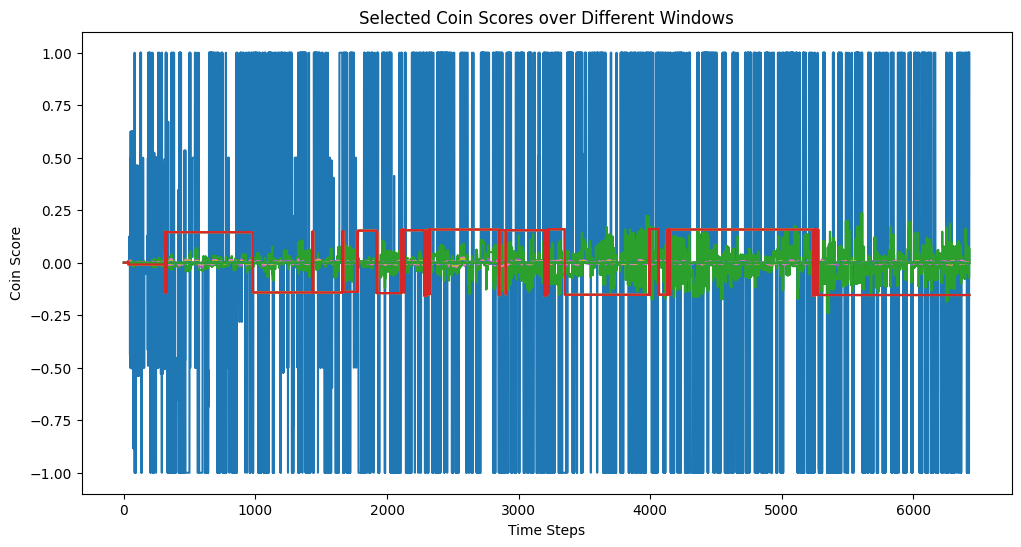

Processing timestamps:  19%|█▊        | 13328/71820 [02:12<09:23, 103.72it/s]

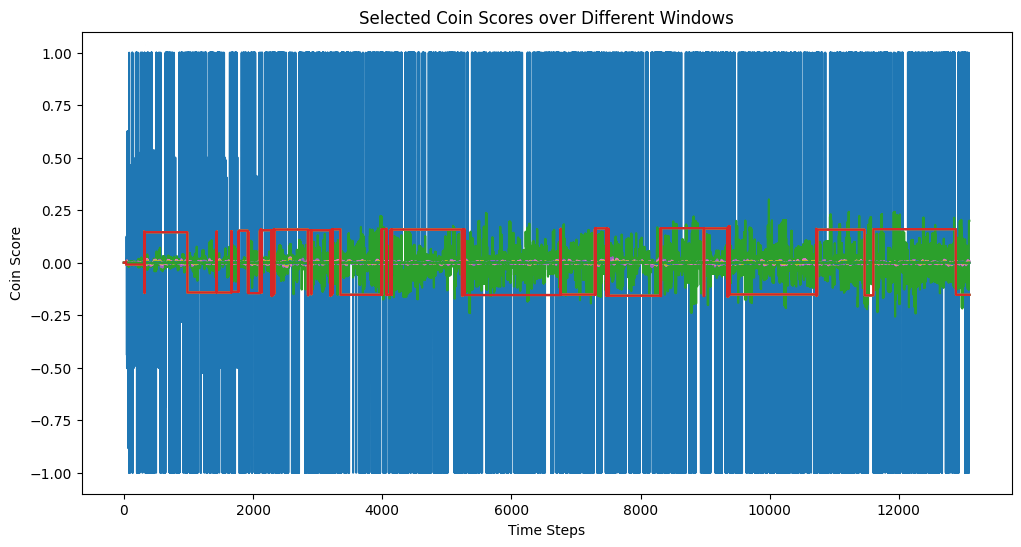

Processing timestamps:  28%|██▊       | 19998/71820 [03:17<08:17, 104.14it/s]

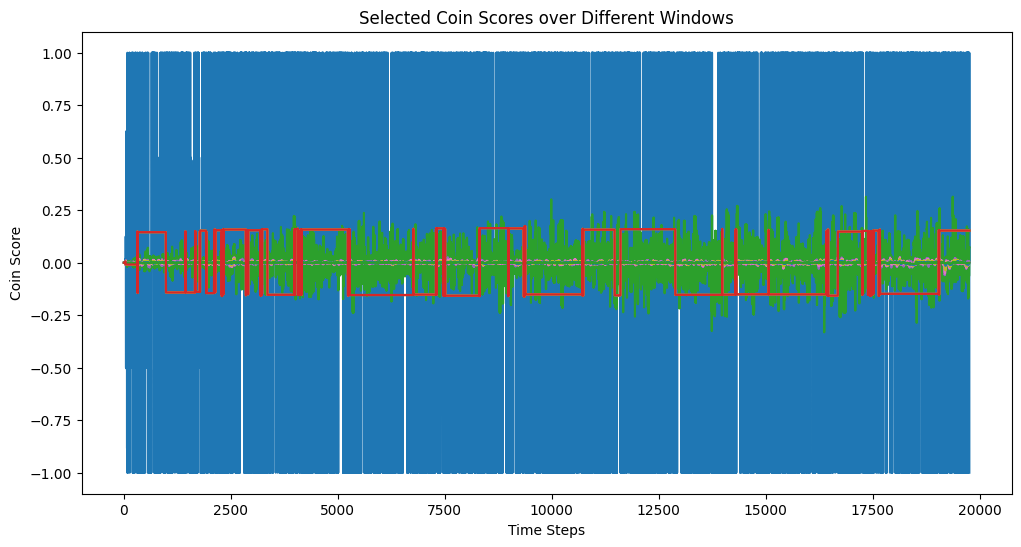

Processing timestamps:  37%|███▋      | 26662/71820 [04:23<07:23, 101.77it/s]

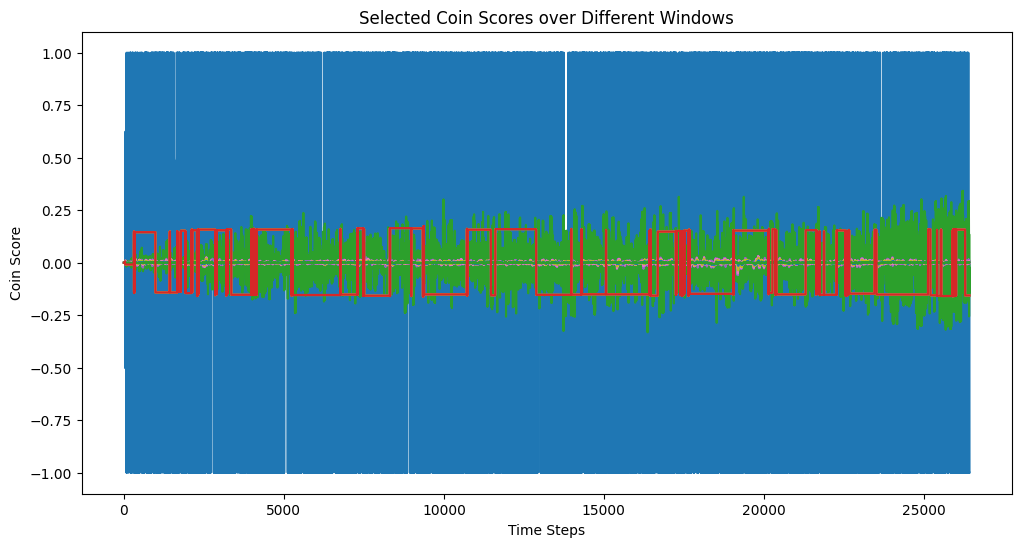

Processing timestamps:  46%|████▋     | 33329/71820 [05:28<06:12, 103.38it/s]

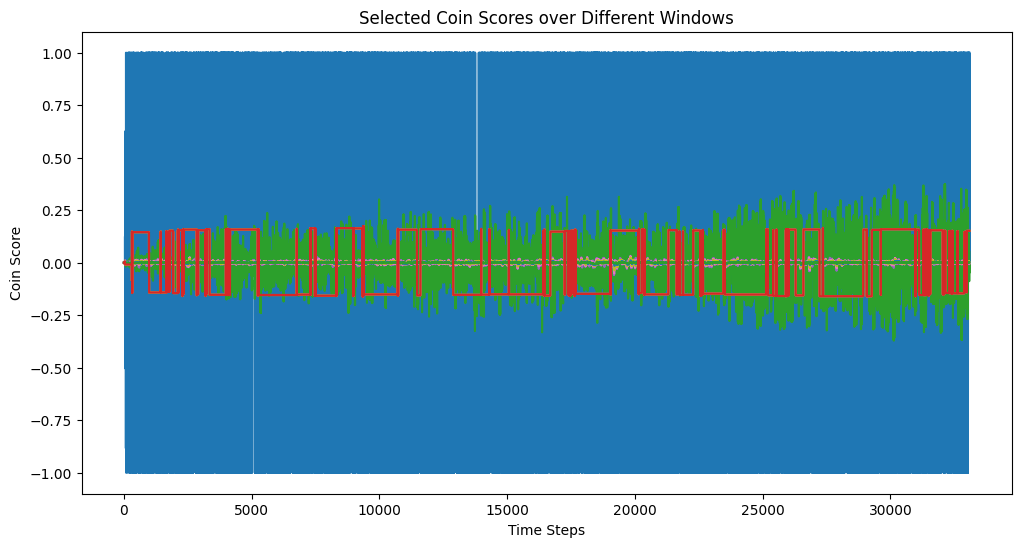

Processing timestamps:  56%|█████▌    | 39990/71820 [06:33<05:04, 104.55it/s]

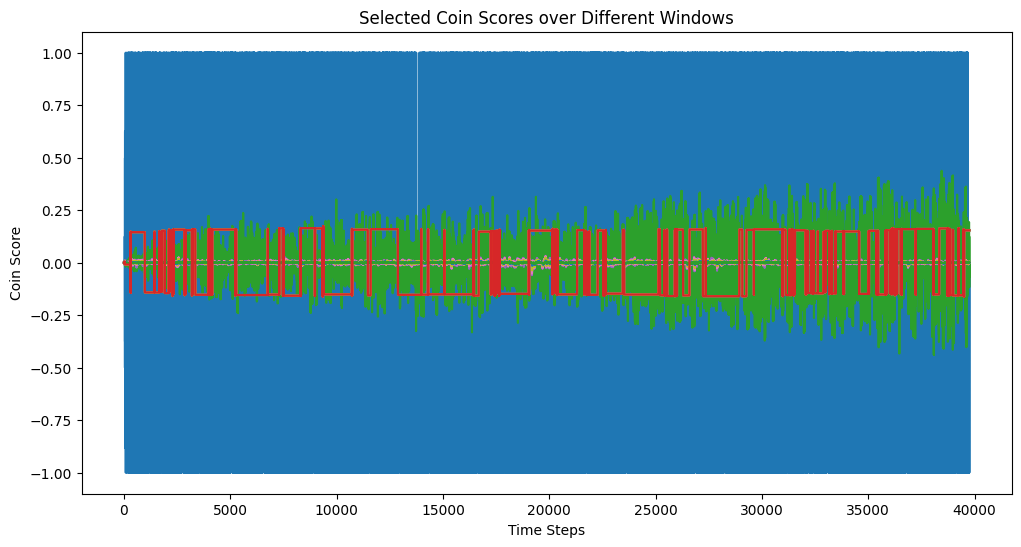

Processing timestamps:  65%|██████▍   | 46662/71820 [07:38<03:58, 105.35it/s]

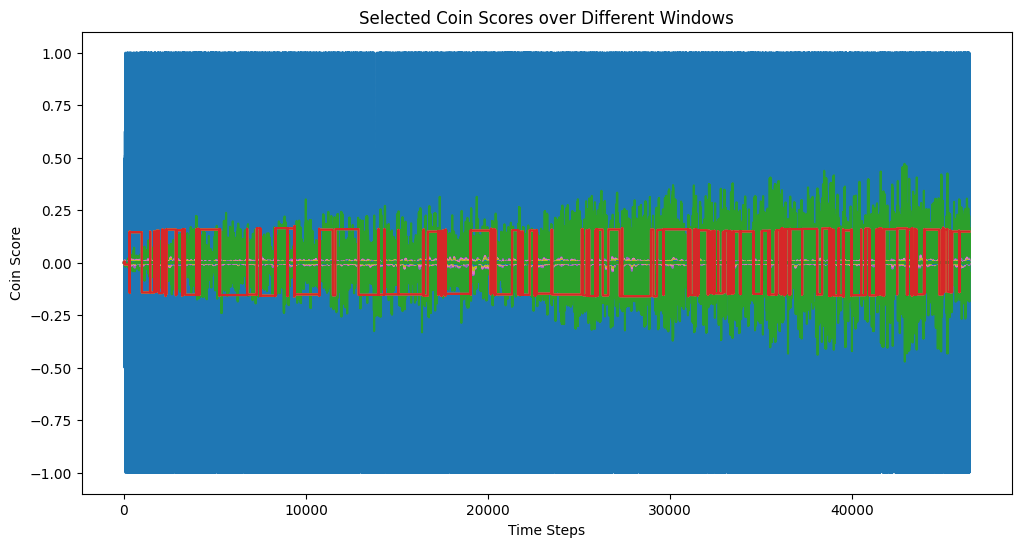

Processing timestamps:  74%|███████▍  | 53321/71820 [08:45<02:59, 102.78it/s]

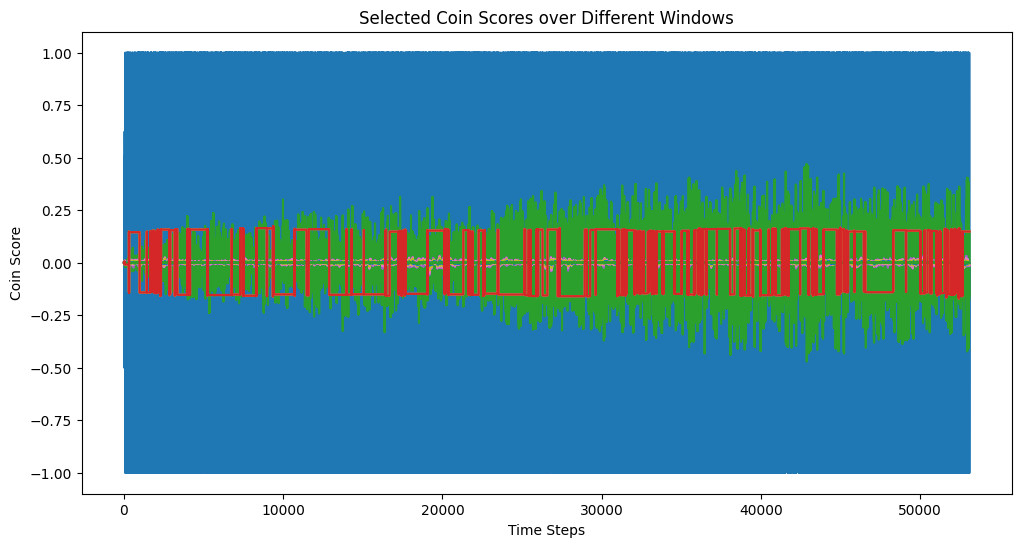

Processing timestamps:  84%|████████▎ | 59988/71820 [09:50<01:54, 103.76it/s]

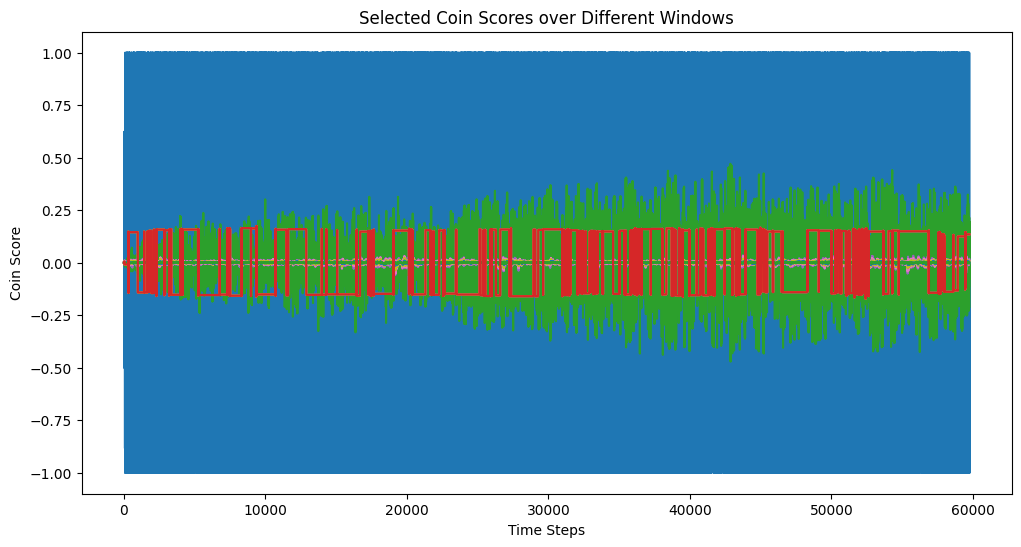

Processing timestamps:  93%|█████████▎| 66659/71820 [10:55<00:49, 103.36it/s]

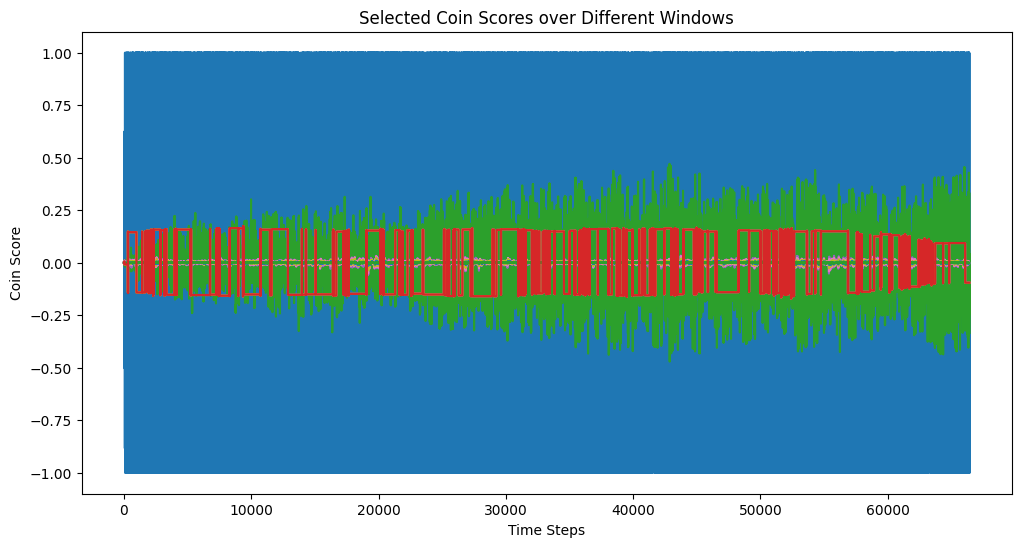

Processing timestamps: 100%|██████████| 71820/71820 [11:47<00:00, 101.56it/s]


In [25]:






for i, t in tqdm(enumerate(common_index), desc="Processing timestamps", total=len(common_index)):
    # Only access data if timestamp exists in all dataframes
    for name, df in data_list.items():
        if t in df.index:
            coin_closes[name].append(df.loc[t, "close"])
            coin_volumes[name].append(df.loc[t, "volume"])
        else:
            print(f"Timestamp {t} not found in {name}, skipping...")
            continue

    if i>=back_window:
        for name, _ in data_list.items():
            if t not in data_list[name].index:
                continue
                
            # growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 
            # mkt_idx_diff = coin_closes['BTCUSDT'][-1] - coin_closes['BTCUSDT'][-2]                
            growth = (np.array(coin_closes[name])[-1]) 
            mkt_idx_diff = coin_closes['BTCUSDT'][-1]
            
            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

                xy_1[name].popleft()
                xx_1[name].popleft()
                yy_1[name].popleft()
                x_1[name].popleft()
                y_1[name].popleft()

            xy_1[name].append(growth*mkt_idx_diff)
            xx_1[name].append(mkt_idx_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_diff)
            y_1[name].append(growth)
            
            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            
            if i >= 2*back_window:
                # Without intercept
                coef_1 = xy_1_sum[name]/xx_1_sum[name] if xx_1_sum[name]!=0 else 0
                residual = np.array(coin_closes[name])[-1] - (coef_1 * (np.array(coin_closes['BTCUSDT'])[-1]))

                # # # With intercept
                # coef_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / (back_window * xx_1_sum[name] - x_1_sum[name]**2) if (back_window * xx_1_sum[name] - x_1_sum[name]**2) != 0 else 0
                # alpha = (y_1_sum[name] - coef_1 * x_1_sum[name]) / back_window if back_window != 0 else 0
                # residual = np.array(coin_closes[name])[-1] - (coef_1 * np.array(coin_closes['BTCUSDT'])[-1] + alpha)

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0


                y = np.asarray(coin_closes[name], dtype=float)
                x = np.asarray(coin_closes["BTCUSDT"], dtype=float)
                if coef_1 != 0:
                    residual_series = (y - coef_1 * x) / coef_1
                else:
                    residual_series = pd.Series(0.0, index=y.index)
                x = residual_series[-1]
                residual_z = np.sum(residual_series < x) + 1

                coef_records.setdefault(name, {})

                # 2. 填充 stat_w
                for stat in stats_nocs_list:
                    for w in windows:
                        stat_col = f"{stat}_{w}"
                        coef_records[name][stat_col] = (
                            data_list[name].loc[t, stat_col]
                            if stat_col in data_list[name].columns
                            else 0
                        )

                # 3. 再补充回归 / 价格字段（不会覆盖）
                coef_records[name].update({
                    'close': data_list[name].loc[t, "close"],
                    'coef_1': coef_1,
                    'coef_1_adj': (
                        coef_1
                        * np.array(coin_closes['BTCUSDT'])[-1]
                        / np.array(coin_closes[name])[-1]
                        if np.array(coin_closes[name])[-1] != 0
                        else 0
                    ),
                    'corr_1': corr_1,
                    'residual': (
                        residual / coef_1 / np.array(coin_closes['BTCUSDT'])[-1]
                        if coef_1 != 0
                        else 0
                    ),
                    'residual_z': residual_z,
                })

        if i >= 2*back_window and len(coef_records) > 1:
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index', dtype=float)  # index=coin
            
            # Select coins based on residual values
            long_coin = coef_df.sort_values(by='residual', ascending=True).index[0]
            short_coin = coef_df.sort_values(by='residual', ascending=False).index[0]

            if lc is None:
                lc = long_coin
                sc = short_coin
            if long_coin != lc:
                lc = long_coin
                dif += 1
            else:
                sam += 1
            if short_coin != sc:
                sc = short_coin
                dif += 1
            else:
                sam += 1

            # 先获取当前价格
            price_long_now = float(coef_df.loc[long_coin, 'close'])
            price_short_now = float(coef_df.loc[short_coin, 'close'])

            # 安全地获取未来价格
            future_long_price = price_long_now  # 默认值
            future_short_price = price_short_now  # 默认值

            residual_diff = float(coef_df.loc[long_coin, 'residual']) - float(coef_df.loc[short_coin, 'residual'])
            residual_mean = coef_df['residual'].mean()
            residual_std = coef_df['residual'].std()
            residual_z_all = coef_df['residual_z'].mean()
            residual_z_selected = (float(coef_df.loc[long_coin, 'residual_z']) + float(coef_df.loc[short_coin, 'residual_z'])) / 2
            residual_sign = np.abs((coef_df['residual'] > 0).sum()-0.5*len(coef_df))
            corr_all = coef_df['corr_1'].mean()
            corr_selected = (float(coef_df.loc[long_coin, 'corr_1']) + float(coef_df.loc[short_coin, 'corr_1'])) / 2
            coef_adj_all = coef_df['coef_1_adj'].mean()
            coef_adj_selected = (float(coef_df.loc[long_coin, 'coef_1_adj']) + float(coef_df.loc[short_coin, 'coef_1_adj'])) / 2

            stats_global["residual_diff"].append(residual_diff)
            stats_global["residual_std"].append(residual_std)
            stats_global["residual_mean"].append(residual_mean)
            stats_global["residual_z_all"].append(residual_z_all)
            stats_global["residual_z_selected"].append(residual_z_selected)
            stats_global["residual_sign"].append(residual_sign)
            stats_global["corr_all"].append(corr_all)
            stats_global["corr_selected"].append(corr_selected)
            stats_global["coef_adj_all"].append(coef_adj_all)
            stats_global["coef_adj_selected"].append(coef_adj_selected)

            if (i + forward_window) < len(common_index):
                future_timestamp = common_index[i + forward_window]
                # 验证未来时间戳在对应coin数据中存在
                if future_timestamp in data_list[long_coin].index:
                    future_long_price = data_list[long_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {long_coin}, using current price")
                
                if future_timestamp in data_list[short_coin].index:
                    future_short_price = data_list[short_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {short_coin}, using current price")

            price_long_fut = float(future_long_price)
            price_short_fut = float(future_short_price)

            coef_1_long = float(coef_df.loc[long_coin, 'coef_1'])
            coef_1_short = float(coef_df.loc[short_coin, 'coef_1'])

            # x_l = coef_1_short*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now) 
            # x_s = coef_1_long*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)

            x_l = bullet_size/2/price_long_now 
            x_s = bullet_size/2/price_short_now

            revenue_l = x_l * (price_long_fut - price_long_now) 
            revenue_s = - x_s * (price_short_fut - price_short_now)
            revenue = revenue_l + revenue_s

            # [stat] coin score
            for coin_name in coef_df.index:
                recent_r = temp_revs[coin_name][0] if len(temp_revs[coin_name])==forward_window + 1 else 0

                for w in windows:
                    # [stat] coin score
                    alpha = back_window / w
                    if recent_r != 0 :
                        coin_scores[coin_name][w] = max(min(1,coin_scores[coin_name][w]*(1 - alpha) + recent_r *alpha), -1)

            for w in windows:
                coin_all = np.mean([coin_scores[coin_name][w] for w in windows])
                coin_selected = (coin_scores[long_coin][w] + coin_scores[short_coin][w]) / 2
                stats_by_window["coin_all"][w].append(coin_all)
                stats_by_window["coin_selected"][w].append(coin_selected)

                for stat in stats_nocs_list:
                    stat_all = coef_df[f"{stat}_{w}"].mean()
                    stat_selected = (float(coef_df.loc[long_coin, f"{stat}_{w}"]) + float(coef_df.loc[short_coin, f"{stat}_{w}"])) / 2
                    stats_by_window[f"{stat}_all"][w].append(stat_all)
                    stats_by_window[f"{stat}_selected"][w].append(stat_selected)

            ## renew
            r_l = revenue_l / (x_l * price_long_now) if x_l * price_long_now !=0 else 0
            r_s = revenue_s / (x_s * price_short_now) if x_s * price_short_now !=0 else 0
            temp_revs[long_coin].append(r_l)
            temp_revs[short_coin].append(r_s)   

            for coin_name in coef_df.index:
                if coin_name != long_coin and coin_name != short_coin:
                    temp_revs[coin_name].append(0)   



            if x_l > 0 and x_s > 0:
                revenues.append(revenue)
                # revenues.append(0)
            else:
                revenues.append(0)


            
            if i % 6666 == 0:
                revenue_series = pd.Series(revenues)
                cumulative_revenue = np.cumsum(revenue_series)
                fig = plt.figure(figsize=(12, 6))
                plt.plot(cumulative_revenue)
                plt.xlabel("Trades")
                plt.ylabel("Cumulative Revenue")
                plt.title("Cumulative Revenue over Trades")
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close(fig)

                plt.figure(figsize=(12, 6))
                for w in windows:
                    plt.plot(stats_by_window["coin_selected"][w], label=f"Window {w}")
                    plt.plot(stats_by_window["coin_all"][w], label=f"Window {w}")
                    # plt.legend()
                    plt.title("Selected Coin Scores over Different Windows")
                    plt.xlabel("Time Steps")
                    plt.ylabel("Coin Score")
                plt.show()
                plt.close()





In [26]:
coin_scores

{'BTCUSDT': {30: 1,
  60: -0.0009319775797845984,
  120: 0.002264468858234598,
  480: 0.0016711714076746357,
  1920: -0.00011520744524388187,
  7680: -0.0005632990648492915,
  30720: -0.0003440464764396344},
 'ETHUSDT': {30: 1,
  60: 0.10148710200985271,
  120: -0.00298570159999563,
  480: -0.0009251781908226429,
  1920: 0.00048038261308308344,
  7680: 0.0011703874379130025,
  30720: 0.0004911449700089818},
 'BNBUSDT': {30: -1,
  60: 0.013927631368851879,
  120: 0.0049859532788336675,
  480: 0.0028251686929411843,
  1920: -3.122760084572749e-05,
  7680: -0.00013679406574773536,
  30720: -0.0008006636631705991},
 'SOLUSDT': {30: -1,
  60: 0.27032501445793394,
  120: 0.0006254619889690409,
  480: 0.0032634879499722305,
  1920: 0.0037932156147086524,
  7680: 0.0006288427776645625,
  30720: -0.0009558254648071002},
 'XRPUSDT': {30: 1,
  60: 0.14382251648954508,
  120: 0.001383081376648502,
  480: -0.01643855662856999,
  1920: -0.019943646691937104,
  7680: -0.009045555109313269,
  30720: -

In [27]:
np.array(revenues).mean()/50*(sam+dif)/sam

np.float64(0.00023771900113242025)

In [28]:
sam, dif

(119980, 23180)

# Stats Summary

Statistics:
Sample size: 71580
Mean (μ): 0.0002
Standard deviation (σ): 0.0053
Median: 0.0003
Skewness: -0.7365
Kurtosis: 7.6882


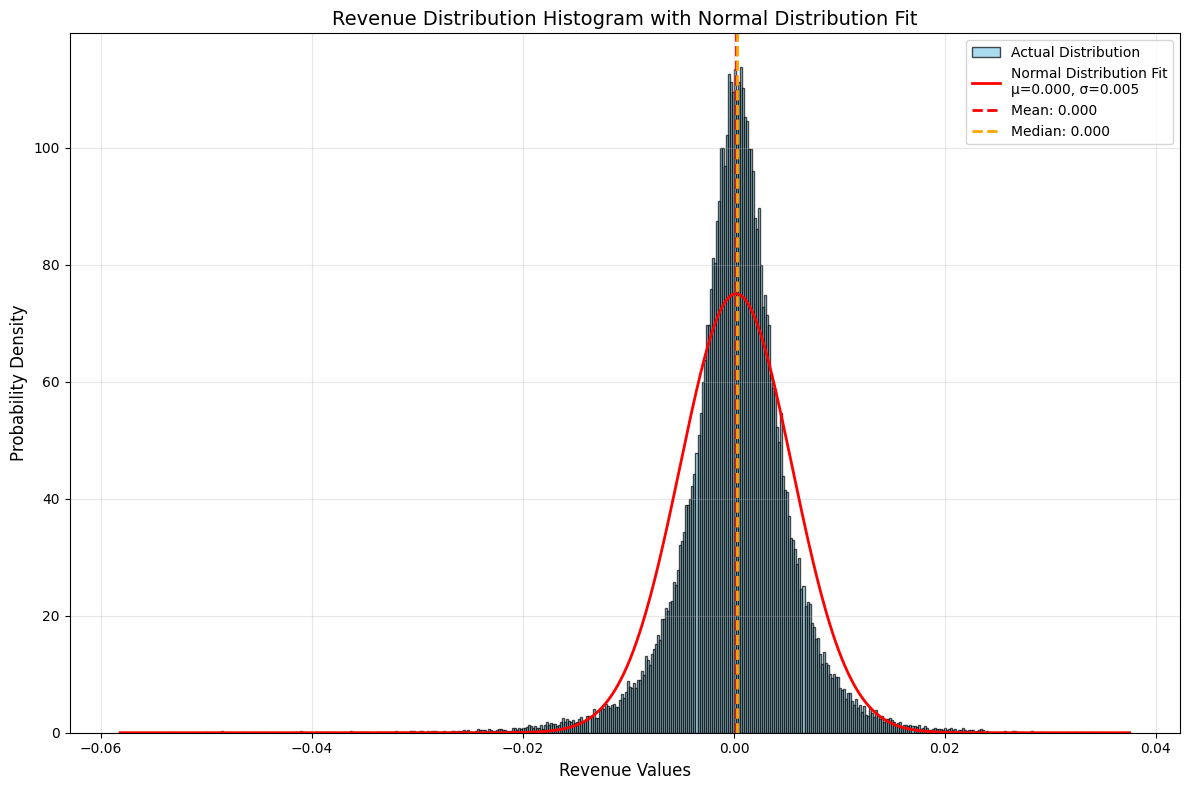


Kolmogorov-Smirnov Normality Test:
Test statistic: 0.0761
p-value: 0.0000e+00
Conclusion: Reject normality assumption

Goodness of Fit:
R² = 0.9055


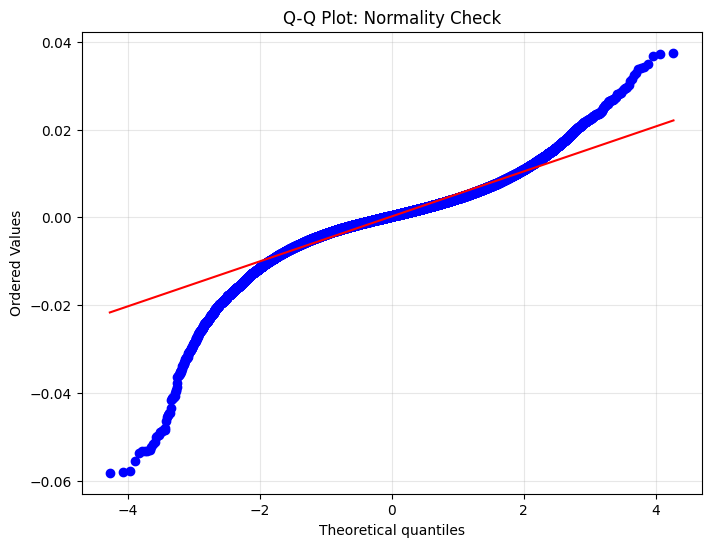


Normal Distribution Fit Results:
Normal Distribution: N(0.0002, 0.0053²)
95% Confidence Interval: [-0.0102, 0.0106]
99% Confidence Interval: [-0.0135, 0.0139]


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm
import seaborn as sns

# Remove NaN values
revenue_data = np.array(revenues)/50

# Calculate statistics
mean_revenue = np.mean(revenue_data)
std_revenue = np.std(revenue_data, ddof=1)  # Sample standard deviation
median_revenue = np.median(revenue_data)
skewness = stats.skew(revenue_data)
kurtosis = stats.kurtosis(revenue_data)

print(f"Statistics:")
print(f"Sample size: {len(revenues)}")
print(f"Mean (μ): {mean_revenue:.4f}")
print(f"Standard deviation (σ): {std_revenue:.4f}")
print(f"Median: {median_revenue:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Create figure
plt.figure(figsize=(12, 8))

# Plot histogram
n_bins = 500
counts, bins, patches = plt.hist(revenue_data, bins=n_bins, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='Actual Distribution')

# Generate normal distribution fit curve
x = np.linspace(revenue_data.min(), revenue_data.max(), 1000)
fitted_normal = norm.pdf(x, mean_revenue, std_revenue)
plt.plot(x, fitted_normal, 'r-', linewidth=2, 
         label=f'Normal Distribution Fit\nμ={mean_revenue:.3f}, σ={std_revenue:.3f}')

# Add mean and median lines
plt.axvline(mean_revenue, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_revenue:.3f}')
plt.axvline(median_revenue, color='orange', linestyle='--', linewidth=2, 
            label=f'Median: {median_revenue:.3f}')

# Plot settings
plt.xlabel('Revenue Values', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Revenue Distribution Histogram with Normal Distribution Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()

# Kolmogorov-Smirnov normality test
ks_statistic, ks_p_value = stats.kstest(revenue_data, 
                                        lambda x: norm.cdf(x, mean_revenue, std_revenue))

# Shapiro-Wilk normality test (suitable for small samples)
if len(revenue_data) <= 5000:
    sw_statistic, sw_p_value = stats.shapiro(revenue_data)
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test statistic: {sw_statistic:.4f}")
    print(f"p-value: {sw_p_value:.4e}")
    print(f"Conclusion: {'Accept normality assumption' if sw_p_value > 0.05 else 'Reject normality assumption'}")

print(f"\nKolmogorov-Smirnov Normality Test:")
print(f"Test statistic: {ks_statistic:.4f}")
print(f"p-value: {ks_p_value:.4e}")
print(f"Conclusion: {'Accept normality assumption' if ks_p_value > 0.05 else 'Reject normality assumption'}")

# Calculate goodness of fit (R²)
bin_centers = (bins[:-1] + bins[1:]) / 2
expected_counts = len(revenue_data) * norm.pdf(bin_centers, mean_revenue, std_revenue) * (bins[1] - bins[0])
observed_counts = counts * len(revenue_data) * (bins[1] - bins[0])

# Calculate R²
ss_res = np.sum((observed_counts - expected_counts) ** 2)
ss_tot = np.sum((observed_counts - np.mean(observed_counts)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"R² = {r_squared:.4f}")

# Plot Q-Q plot for normality check
plt.figure(figsize=(8, 6))
stats.probplot(revenue_data, dist="norm", plot=plt)
plt.title('Q-Q Plot: Normality Check')
plt.grid(True, alpha=0.3)
plt.show()

# Output normal distribution parameter summary
print(f"\nNormal Distribution Fit Results:")
print(f"Normal Distribution: N({mean_revenue:.4f}, {std_revenue:.4f}²)")
print(f"95% Confidence Interval: [{mean_revenue - 1.96*std_revenue:.4f}, {mean_revenue + 1.96*std_revenue:.4f}]")
print(f"99% Confidence Interval: [{mean_revenue - 2.58*std_revenue:.4f}, {mean_revenue + 2.58*std_revenue:.4f}]")

In [30]:
revenue_series = pd.Series(revenues)

# for stat in stats_global.keys():
#     series = pd.Series(stats_global[stat])
#     revenue_series = revenue_series.iloc[-len(series):]
#     corr = series.corr(revenue_series)
#     print(f"Correlation between {stat} and revenues: {corr:.4f}")
#     # series.to_csv(f"stat_{stat}.csv", index=False)


In [31]:
# revenue_series.to_csv("revenues.csv", index=False)

In [32]:
revenue_series.max(), revenue_series.min(), revenue_series.mean(), revenue_series.std()

(np.float64(1.8752123538610561),
 np.float64(-2.909934680469481),
 np.float64(0.0099614158130301),
 np.float64(0.2658238800862981))

In [33]:
fit_ratio = 0.8 # 70% 用于训练，30% 用于测试
split_index = int(len(revenue_series) * fit_ratio)
train_revenues = revenue_series[:split_index]
test_revenues = revenue_series[split_index:]
train_revenue_series = np.array(train_revenues)
test_revenue_series = np.array(test_revenues)

train_stats = {}
test_stats = {}
for stat in stats_global.keys():
    series = pd.Series(stats_global[stat])
    train_stats[stat] = series[:split_index] 
    test_stats[stat] = series[split_index:]
for stat in stats_by_window.keys():

    for w in windows:

        series = pd.Series(stats_by_window[stat][w])
        if len(series) != len(revenue_series):
            print(f"Length mismatch for {stat} window {w}: series length {len(series)}, revenue_series length {len(revenue_series)}")
            continue
        train_stats[f"{stat}_w{w}"] = series[:split_index]
        test_stats[f"{stat}_w{w}"] = series[split_index:]

In [34]:
train_stats

{'residual_diff': 0       -0.018079
 1       -0.017993
 2       -0.016599
 3       -0.013032
 4       -0.011386
            ...   
 57259   -0.023270
 57260   -0.022830
 57261   -0.022890
 57262   -0.022269
 57263   -0.020797
 Length: 57264, dtype: float64,
 'residual_std': 0        0.003319
 1        0.003285
 2        0.003216
 3        0.002917
 4        0.002711
            ...   
 57259    0.004474
 57260    0.004338
 57261    0.004459
 57262    0.004441
 57263    0.004230
 Length: 57264, dtype: float64,
 'residual_mean': 0        0.002518
 1        0.001955
 2        0.001631
 3        0.001066
 4        0.000807
            ...   
 57259   -0.003355
 57260   -0.003715
 57261   -0.004850
 57262   -0.005318
 57263   -0.005090
 Length: 57264, dtype: float64,
 'residual_z_all': 0        86.641026
 1        81.307692
 2        75.743590
 3        69.358974
 4        65.307692
            ...    
 57259    34.923077
 57260    31.282051
 57261    23.974359
 57262    21.256410
 57263   

In [35]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# n_bins = 50  # 分箱数量，可调整

# for stat_name, stats in train_stats.items():
#     i = stat_name
#     df = pd.DataFrame({
#         "stats": stats,
#         "revenue": train_revenue_series
#     }).dropna()

#     # 等频分箱（推荐用于分布不均）
#     df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

#     # 分箱统计
#     bin_stats = df.groupby("bin")["revenue"].agg(
#         count="count",
#         mean="mean",
#         median="median",
#         std="std"
#     )

#     # ===== 1. 原始散点图 =====
#     plt.figure(figsize=(10, 6))
#     plt.scatter(df["stats"], df["revenue"], s=1)
#     plt.xlabel("stats")
#     plt.ylabel("revenue")
#     plt.title(f"Scatter Plot (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 2. 分箱箱线图 =====
#     plt.figure(figsize=(12, 6))
#     df.boxplot(
#         column="revenue",
#         by="bin",
#         showfliers=False,
#         grid=False
#     )
#     plt.xticks(rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Revenue")
#     plt.title(f"Binned Boxplot (stats_{i})")
#     plt.suptitle("")
#     plt.show()
#     plt.close()

#     # ===== 3. 分箱均值曲线 =====
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         range(len(bin_stats)),
#         bin_stats["mean"].values,
#         marker="o"
#     )
#     plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Mean revenue")
#     plt.title(f"Binned Mean Revenue (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 4. 输出统计表 =====
#     print(f"\nSummary statistics for stats_{i}:")
#     print(bin_stats)


In [36]:
len(train_revenue_series), len(train_stats['residual_diff'])

(57264, 57264)

# Factor Model

## Evaluation Function

In [37]:
y_train=train_revenue_series/50 * 10000
X_train=pd.DataFrame(train_stats)

y_test=test_revenue_series/50 * 10000
X_test=pd.DataFrame(test_stats)
def model_evaluation(y_true, y_pred, dataset_type="Train",thres = 5,if_plot=True, if_stats=True):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)

    y_true_filtered = []
    for i in range(len(y_true)):
        if y_pred[i] >thres:
            y_true_filtered.append(y_true[i])
        

    
    # 绘制折线图
    if if_plot:
        plt.figure(figsize=(12, 8))
        
        # 主图：均值对比
        plt.subplot(2, 1, 1)
        plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
        plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
        plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                    label=f'Overall True Mean: {overall_true_mean:.4f}')
        plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                    label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
        plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
                label=f'cost baseline: 10')
        
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Mean Value')
        plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 副图：样本数量
        plt.subplot(2, 1, 2)
        plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Sample Count')
        plt.title('Sample Count by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    if if_stats:
        # 输出基本评估指标
        print(f"{dataset_type} Set Evaluation:")
        print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
        print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Overall True Mean: {overall_true_mean:.4f}")
        print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
        
        # 输出百分位分析表
        percentile_df = pd.DataFrame({
            'Percentile': percentiles,
            'True_Mean': true_means,
            'Pred_Mean': pred_means,
            'Sample_Count': sample_counts,
            'Mean_Diff': np.array(pred_means) - np.array(true_means)
        })
        
        print(f"{dataset_type} Set Percentile Analysis:")
        print(percentile_df.round(4))
    return len(y_true_filtered), np.mean(y_true_filtered),

    # # return percentile_df

In [38]:
# Check for NaN values in X_test
nan_check = X_train.isna().sum()

# Print columns with NaN values
print("Columns with NaN values:")
print(nan_check[nan_check > 0])

# Fill NaN values with 0
X_train.fillna(0, inplace=True)

Columns with NaN values:
Series([], dtype: int64)


In [39]:
# Check for NaN values in X_test
nan_check = X_test.isna().sum()

# Print columns with NaN values
print("Columns with NaN values:")
print(nan_check[nan_check > 0])

# Fill NaN values with 0
X_test.fillna(0, inplace=True)

Columns with NaN values:
Series([], dtype: int64)


In [40]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]

print(f"Number of rows with infinity values: {inf_mask.sum()}")
print(f"Total rows in X_train: {len(X_train)}")
print(f"Percentage of rows with infinity: {inf_mask.sum() / len(X_train) * 100:.2f}%")

if len(invalid_rows) > 0:
    print("\nRows with infinity values:")
    print(invalid_rows)
    
    # Show which columns contain infinity values
    inf_columns = X_train.columns[np.isinf(X_train).any(axis=0)]
    print(f"\nColumns containing infinity values: {list(inf_columns)}")
    
    # Count infinity values per column
    inf_count_per_column = np.isinf(X_train).sum()
    inf_count_per_column = inf_count_per_column[inf_count_per_column > 0]
    print("\nInfinity count per column:")
    for col, count in inf_count_per_column.items():
        print(f"  {col}: {count}")
    
    # Show first few rows with infinity for inspection
    print(f"\nFirst 5 rows with infinity values:")
    print(invalid_rows.head())
    
else:
    print("No infinity values found in X_train.")

# Method 2: Check for both positive and negative infinity separately
pos_inf_mask = np.isposinf(X_train).any(axis=1)
neg_inf_mask = np.isneginf(X_train).any(axis=1)

print(f"\nRows with positive infinity: {pos_inf_mask.sum()}")
print(f"Rows with negative infinity: {neg_inf_mask.sum()}")

Checking for infinity values in X_train...
Number of rows with infinity values: 0
Total rows in X_train: 57264
Percentage of rows with infinity: 0.00%
No infinity values found in X_train.

Rows with positive infinity: 0
Rows with negative infinity: 0


In [41]:
X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_sign,corr_all,corr_selected,coef_adj_all,coef_adj_selected,...,std_all_w1920,std_all_w7680,std_all_w30720,std_selected_w30,std_selected_w60,std_selected_w120,std_selected_w480,std_selected_w1920,std_selected_w7680,std_selected_w30720
0,-0.018079,0.003319,0.002518,86.641026,69.0,10.5,0.425206,0.544246,0.997499,0.996360,...,0.001167,0.000952,0.001174,0.001251,0.001026,0.000951,0.001120,0.001635,0.001134,0.001102
1,-0.017993,0.003285,0.001955,81.307692,64.0,9.5,0.440471,0.335495,0.998059,0.997072,...,0.001167,0.000952,0.001174,0.002313,0.001795,0.001358,0.001097,0.001112,0.000927,0.001247
2,-0.016599,0.003216,0.001631,75.743590,75.0,6.5,0.452388,0.543673,0.998382,0.995510,...,0.001167,0.000952,0.001174,0.001189,0.001041,0.000940,0.001120,0.001635,0.001134,0.001102
3,-0.013032,0.002917,0.001066,69.358974,64.0,7.5,0.459294,0.348352,0.998943,0.997312,...,0.001167,0.000951,0.001174,0.002409,0.001850,0.001395,0.001107,0.001115,0.000927,0.001247
4,-0.011386,0.002711,0.000807,65.307692,75.5,2.5,0.464638,0.315272,0.999200,0.997812,...,0.001167,0.000951,0.001174,0.001004,0.001073,0.001095,0.001507,0.002275,0.001476,0.001431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57259,-0.023270,0.004474,-0.003355,34.923077,50.5,9.5,0.748275,0.576843,1.003386,1.005406,...,0.001464,0.001534,0.001223,0.002523,0.002735,0.002733,0.002537,0.001830,0.001892,0.001425
57260,-0.022830,0.004338,-0.003715,31.282051,52.0,12.5,0.743700,0.565892,1.003747,1.005019,...,0.001464,0.001534,0.001223,0.002506,0.002735,0.002718,0.002533,0.001830,0.001892,0.001425
57261,-0.022890,0.004459,-0.004850,23.974359,49.0,14.5,0.742267,0.561306,1.004894,1.007264,...,0.001464,0.001534,0.001223,0.002566,0.002760,0.002722,0.002533,0.001831,0.001892,0.001425
57262,-0.022269,0.004441,-0.005318,21.256410,45.5,15.5,0.738815,0.553763,1.005366,1.007969,...,0.001464,0.001534,0.001223,0.002553,0.002723,0.002721,0.002533,0.001831,0.001892,0.001425


In [42]:

# Drop columns with infinity values
X_train = X_train.drop(columns=inf_columns)
print(f"Columns with infinity values have been dropped. Remaining columns: {X_train.columns}")



NameError: name 'inf_columns' is not defined

In [ ]:

# Drop columns with infinity values
X_test = X_test.drop(columns=inf_columns)
print(f"Columns with infinity values have been dropped. Remaining columns: {X_test.columns}")

KeyError: "['coin_all_w30', 'coin_all_w60', 'coin_all_w120', 'coin_all_w480', 'coin_all_w1920', 'coin_all_w7680', 'coin_all_w30720', 'coin_selected_w30'] not found in axis"

## Linear

In [43]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)


## Rolling Window

In [ ]:
# def evaluate_ratio_batch(X_all, y_all, ratio: int, batch: int):
#     nums = []
#     means = []
#     for i in range(0, len(y_all), batch):
#         if i + (ratio+1)*batch > len(y_all):
#             break
#         X_batch = X_all.iloc[i:i+ratio*batch]
#         y_batch = y_all[i:i+ratio*batch]
#         X_next = X_all.iloc[i+ratio*batch:i+(ratio+1)*batch]
#         y_next = y_all[i+ratio*batch:i+(ratio+1)*batch]
#         model  = LinearRegression()
#         model.fit(X_batch, y_batch)
#         y_next_pred = model.predict(X_next)
#         # print(f"--------------------- Batch {i//batch + 1} ---------------------")
#         n,m=model_evaluation(y_next, y_next_pred, thres=20, dataset_type=f"Batch {i//batch + 1}", if_plot=False, if_stats=False)
#         nums.append(n)
#         means.append(m)
#     nm_df = pd.DataFrame({
#         "num": nums,
#         "mean": means,
#         "mult": np.array(nums)*np.array(means)
#     })
#     mean_rev = nm_df["mult"].sum()/nm_df["num"].sum()
#     pct = nm_df["num"].sum()/len(y_all)
#     pos = 1 if mean_rev > 5 and pct > 0.005 else -1
#     score = abs((mean_rev-5) * (pct-0.005))*pos
#     if not np.isfinite(score):
#         return 0.0
#     print(f"[DEBUG][EVAL] ratio={ratio}, batch={batch}, score={score:.6f}, mean={mean_rev:.3f}, pct={pct:.3f}")
#     return score

# def grad_ratio(X_all, y_all, ratio, batch):
#     f0 = evaluate_ratio_batch(X_all, y_all, ratio, batch)
#     f_plus = evaluate_ratio_batch(X_all, y_all, ratio + 10, batch)

#     if ratio > 10:
#         f_minus = evaluate_ratio_batch(X_all, y_all, ratio - 10, batch)
#         g = 0.5 * (f_plus - f_minus)
#     else:
#         g = f_plus - f0
#     print(f"[DEBUG][GRAD_RATIO] r={ratio}, g={g:.6f}, f+={f_plus:.6f}, f0={f0:.6f}")
#     return g if np.isfinite(g) else 0.0

# def grad_batch(X_all, y_all, ratio, batch):
#     f0 = evaluate_ratio_batch(X_all, y_all, ratio, batch)
#     f_plus = evaluate_ratio_batch(X_all, y_all, ratio, batch + 150)

#     if batch > 150:
#         f_minus = evaluate_ratio_batch(X_all, y_all, ratio, batch - 150)
#         g = 0.5 * (f_plus - f_minus)
#     else:
#         g = f_plus - f0
#     print(f"[DEBUG][GRAD_BATCH] b={batch}, g={g:.6f}, f+={f_plus:.6f}, f0={f0:.6f}")
#     return g if np.isfinite(g) else 0.0


# def update_param(x, grad, lr, x_min, x_max):
#     if not np.isfinite(grad):
#         return x

#     x_new = x + lr * grad

#     if not np.isfinite(x_new):
#         return x

#     x_new = int(round(x_new))
#     print(f"[DEBUG][UPDATE] x={x}, grad={grad:.6f}, lr={lr}, new={x_new}")
#     return int(np.clip(x_new, x_min, x_max))
# def gd_optimize_ratio_batch_pm1(
#     X_all, y_all,
#     ratio_init=2,
#     batch_init=1000,
#     lr_ratio=50.0,
#     lr_batch=50.0,
#     ratio_min=1,
#     ratio_max=50,
#     batch_min=200,
#     batch_max=10000,
#     n_iters=20
# ):
#     ratio, batch = ratio_init, batch_init
#     history = []

#     for t in range(n_iters):
#         g_r = grad_ratio(X_all, y_all, ratio, batch)
#         g_b = grad_batch(X_all, y_all, ratio, batch)

#         ratio = update_param(ratio, g_r, lr_ratio, ratio_min, ratio_max)
#         batch = update_param(batch, g_b, lr_batch, batch_min, batch_max)

#         score = evaluate_ratio_batch(X_all, y_all, ratio, batch)

#         history.append({
#             "iter": t,
#             "ratio": ratio,
#             "batch": batch,
#             "grad_ratio": g_r,
#             "grad_batch": g_b,
#             "score": score
#         })
#         print("========================================= ")

#         print(f"Iter {t}: ratio={ratio}, batch={batch}, score={score:.4f}")

#     return pd.DataFrame(history)



# X_all = pd.concat([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])

# df_hist = gd_optimize_ratio_batch_pm1(
#     X_all, y_all,
#     ratio_init=20,
#     batch_init=2000,
#     lr_ratio=100.0,
#     lr_batch=5000.0,
#     n_iters=20
# )

# print(df_hist)


In [ ]:
# X_all = pd.concat([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])

# ratio = 30
# batch = 2500


# nums = []
# means = []
# for i in range(0, len(y_all), batch):
#     if i + (ratio+1)*batch > len(y_all):
#         break
#     X_batch = X_all.iloc[i:i+ratio*batch]
#     y_batch = y_all[i:i+ratio*batch]
#     X_next = X_all.iloc[i+ratio*batch:i+(ratio+1)*batch]
#     y_next = y_all[i+ratio*batch:i+(ratio+1)*batch]
#     model  = LinearRegression()
#     model.fit(X_batch, y_batch)
#     y_next_pred = model.predict(X_next)
#     # print(f"--------------------- Batch {i//batch + 1} ---------------------")
#     n,m=model_evaluation(y_next, y_next_pred, thres=25, dataset_type=f"Batch {i//batch + 1}", if_plot=False, if_stats=False)
#     nums.append(n)
#     means.append(m)
# nm_df = pd.DataFrame({
#     "num": nums,
#     "mean": means,
#     "mult": np.array(nums)*np.array(means)
# })
# mean_rev = nm_df["mult"].sum()/nm_df["num"].sum()
# pct = nm_df["num"].sum()/len(y_all)
# score = (mean_rev-5) * pct
# print(f"Mean revenue above threshold: {mean_rev:.4f}, Percentage of samples: {pct:.4f}, Score: {score:.4f}")

In [ ]:
# mult_cum = nm_df["mult"].cumsum()
# plt.figure(figsize=(10, 6))
# plt.plot(mult_cum)
# plt.xlabel("Batches")
# plt.ylabel("Cumulative Mean Revenue")
# plt.title("Cumulative Mean Revenue over Batches")
# plt.grid(True, alpha=0.3)
# plt.show()

## ML

In [ ]:
pip install lightgbm

python(3256) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


/Users/lizeyu/Desktop/Quant-on-Crypto/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
# Convert numpy arrays to pandas DataFrames or Series
y_train_df = pd.DataFrame(y_train, columns=["y_train"])
y_test_df = pd.DataFrame(y_test, columns=["y_test"])

# Save to CSV
X_train.to_csv("X_train.csv", index=False)
y_train_df.to_csv("y_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_test_df.to_csv("y_test.csv", index=False)

In [ ]:
# import numpy as np
# import lightgbm as lgb
# from sklearn.metrics import mean_squared_error

# # ===============================
# # 1. 随机划分 80% / 20%（模拟你原来的 90/10 early stop）
# # ===============================
# random_index = np.random.permutation(len(X_train))
# split = int(0.8 * len(X_train))

# X_train_80 = X_train.iloc[random_index[:split]]
# y_train_80 = y_train[random_index[:split]]

# X_train_20 = X_train.iloc[random_index[split:]]
# y_train_20 = y_train[random_index[split:]]

# # ===============================
# # 2. 定义 LightGBM 回归模型
# # ===============================
# model = lgb.LGBMRegressor(
#     objective="regression",
#     metric="mse",
#     boosting_type="gbdt",

#     n_estimators=5000,        # 给足树数，early stopping 决定最终用多少
#     learning_rate=0.03,

#     num_leaves=31,            # 4 维特征的稳妥取值
#     max_depth=-1,

#     min_data_in_leaf=200,     # 防止过拟合（≈ RF 的 min_samples_leaf）
#     min_gain_to_split=0.0,

#     subsample=0.8,            # ≈ max_samples
#     subsample_freq=1,
#     colsample_bytree=0.8,     # ≈ max_features

#     reg_lambda=1.0,

#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

# # ===============================
# # 3. 训练（Early Stopping）
# # ===============================
# print("Training LightGBM with early stopping...")

# model.fit(
#     X_train_80,
#     y_train_80,
#     eval_set=[(X_train_20, y_train_20)],
#     eval_metric="mse",
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=100, verbose=True)
#     ]
# )

# # ===============================
# # 4. 验证集评估
# # ===============================
# val_pred = model.predict(X_train_20, num_iteration=model.best_iteration_)
# val_mse = mean_squared_error(y_train_20, val_pred)

# print(f"Validation MSE: {val_mse:.6f}")
# print(f"Best iteration: {model.best_iteration_}")

# # ===============================
# # 5. 全量预测
# # ===============================
# y_train_pred = model.predict(X_train, num_iteration=model.best_iteration_)
# y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

# # ===============================
# # 6. 可选：特征重要性
# # ===============================
# feature_importance = model.feature_importances_

# print("Feature importance:", feature_importance)


In [ ]:
pip install xgboost

/Users/lizeyu/Desktop/Quant-on-Crypto/.venv/bin/python: No module named pip


python(3262) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=250,
    
    max_samples=0.8,
    max_features=0.8,
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_index = np.random.permutation(len(X_train))
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[random_index[:split]]
y_train_80 = y_train[random_index[:split]]

X_train_20 = X_train.iloc[random_index[split:]]
y_train_20 = y_train[random_index[split:]]

# 训练模型
print("Training Random Forest...")
model.fit(X_train_80, y_train_80)

# 验证集评估
val_pred = model.predict(X_train_20)
val_mse = mean_squared_error(y_train_20, val_pred)
print(f"Validation MSE: {val_mse:.6f}")

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

print("Feature importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"  {name}: {importance:.4f}")

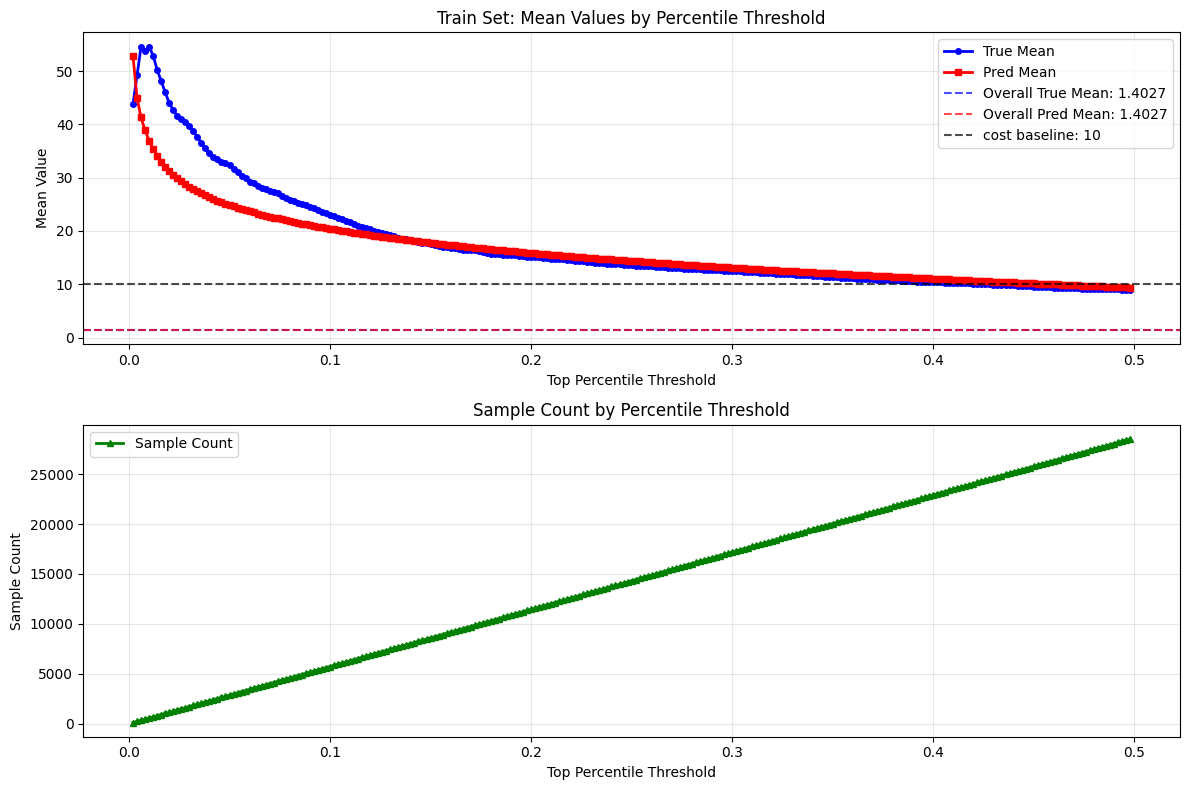

Train Set Evaluation:
  MAE: 35.9014, Relative MAE: 0.6841
  RMSE: 51.4550, Relative RMSE: 0.9805
  R²: 0.0387
  Overall True Mean: 1.4027
  Overall Pred Mean: 1.4027

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    43.7886    52.7846           115     8.9959
1         0.004    49.1788    45.0040           230    -4.1749
2         0.006    54.5740    41.2990           344   -13.2750
3         0.008    53.7084    38.8618           459   -14.8466
4         0.010    54.6099    36.9570           573   -17.6530
..          ...        ...        ...           ...        ...
244       0.490     9.0724     9.4906         28059     0.4182
245       0.492     9.0290     9.4577         28174     0.4287
246       0.494     8.9947     9.4252         28288     0.4305
247       0.496     8.9867     9.3925         28403     0.4058
248       0.498     8.9691     9.3602         28517     0.3911

[249 rows x 5 columns]


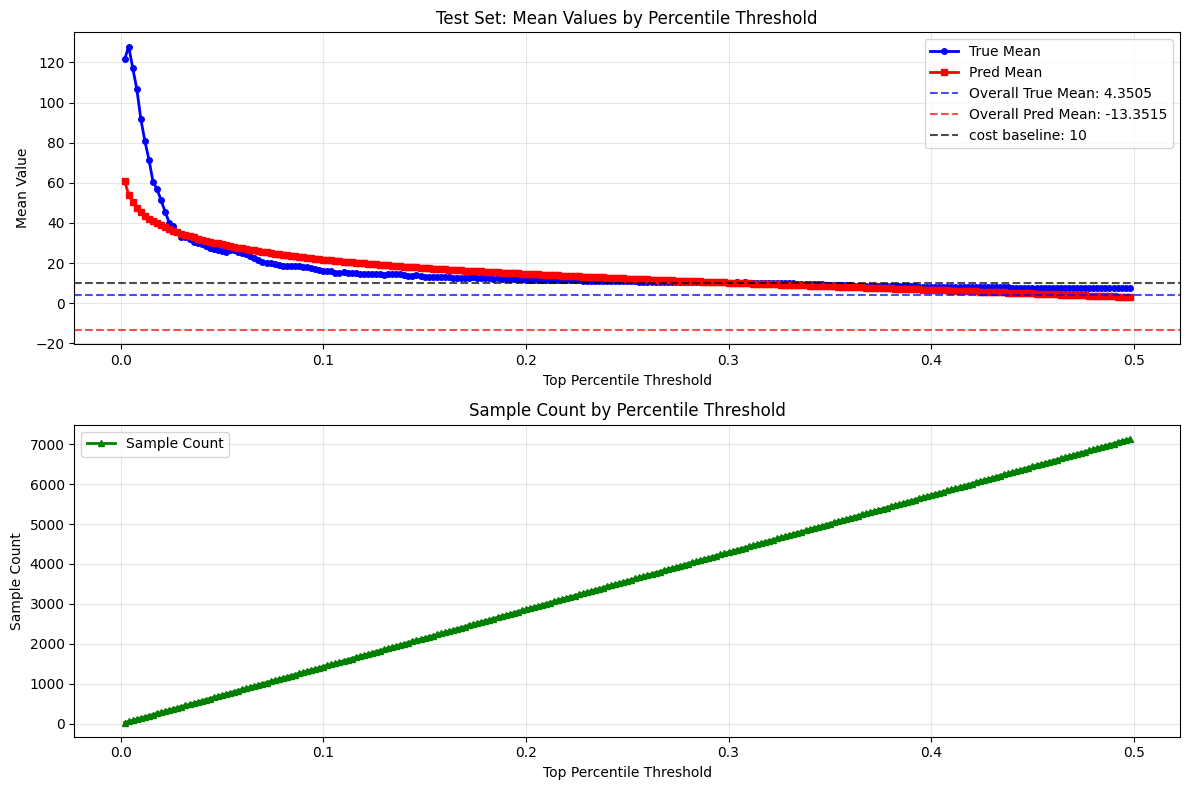

Test Set Evaluation:
  MAE: 43.9612, Relative MAE: 0.7885
  RMSE: 59.9040, Relative RMSE: 1.0744
  R²: -0.1544
  Overall True Mean: 4.3505
  Overall Pred Mean: -13.3515

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   121.6578    60.7920            29   -60.8659
1         0.004   127.9581    54.0869            58   -73.8712
2         0.006   117.1210    50.4894            86   -66.6316
3         0.008   106.7506    47.6471           115   -59.1035
4         0.010    91.7002    45.3935           144   -46.3067
..          ...        ...        ...           ...        ...
244       0.490     7.7236     3.4027          7015    -4.3209
245       0.492     7.7043     3.3309          7043    -4.3734
246       0.494     7.7078     3.2564          7072    -4.4514
247       0.496     7.7098     3.1819          7101    -4.5279
248       0.498     7.6443     3.1100          7129    -4.5343

[249 rows x 5 columns]


(2740, np.float64(12.102015872610087))

In [44]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [45]:
y_true_filtered = []
for i in range(len(y_test)):
    if y_test_pred[i] >15:
        y_true_filtered.append(y_test[i])
    else:
        y_true_filtered.append(0)




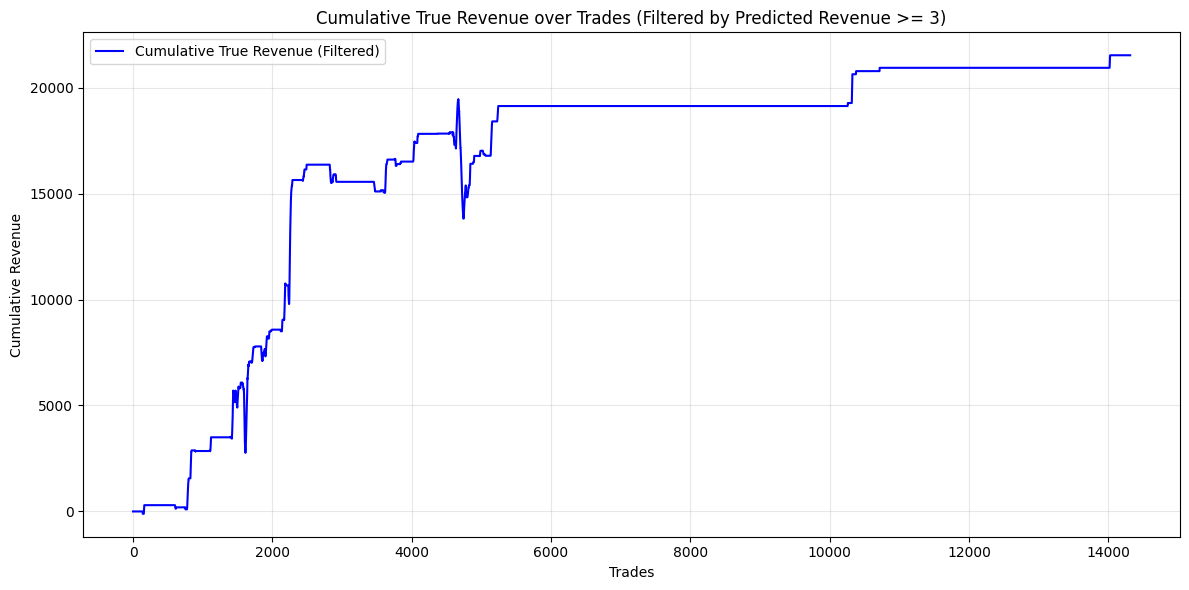

In [46]:
y_true_filtered_cumsum = np.cumsum(y_true_filtered)

plt.figure(figsize=(12, 6))
plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
plt.xlabel('Trades')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:

# for stat_name, stats in test_stats.items():
#     i = stat_name
#     df = pd.DataFrame({
#         "stats": stats,
#         "revenue": test_revenue_series
#     }).dropna()

#     # 等频分箱（推荐用于分布不均）
#     df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

#     # 分箱统计
#     bin_stats = df.groupby("bin")["revenue"].agg(
#         count="count",
#         mean="mean",
#         median="median",
#         std="std"
#     )

#     # ===== 1. 原始散点图 =====
#     plt.figure(figsize=(10, 6))
#     plt.scatter(df["stats"], df["revenue"], s=1)
#     plt.xlabel("stats")
#     plt.ylabel("revenue")
#     plt.title(f"Scatter Plot (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 2. 分箱箱线图 =====
#     plt.figure(figsize=(12, 6))
#     df.boxplot(
#         column="revenue",
#         by="bin",
#         showfliers=False,
#         grid=False
#     )
#     plt.xticks(rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Revenue")
#     plt.title(f"Binned Boxplot (stats_{i})")
#     plt.suptitle("")
#     plt.show()
#     plt.close()

#     # ===== 3. 分箱均值曲线 =====
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         range(len(bin_stats)),
#         bin_stats["mean"].values,
#         marker="o"
#     )
#     plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Mean revenue")
#     plt.title(f"Binned Mean Revenue (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 4. 输出统计表 =====
#     print(f"\nSummary statistics for stats_{i}:")
#     print(bin_stats)
